In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os
import numpy as np
from tqdm.auto import tqdm

# Обучаю на маке
DEVICE = torch.device("mps")

EPOCH = 10
BATCH_SIZE = 100
LR = 0.01

DATA_ROOT = "./data"
STATE_DIR = "state"
STATE_PATH = f"{STATE_DIR}/ogre_magi_state.pt"

/Users/ix8oio8xi/chistoviki-un/vthbnpcew-2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Датасет

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

mnist_train = datasets.MNIST(
    DATA_ROOT, train=True, download=True, transform=transform
)
mnist_test = datasets.MNIST(
    DATA_ROOT, train=False, download=True, transform=transform
)
fashion_train = datasets.FashionMNIST(
    DATA_ROOT, train=True, download=True, transform=transform
)
fashion_test = datasets.FashionMNIST(
    DATA_ROOT, train=False, download=True, transform=transform
)

mnist_train_loader = DataLoader(
    mnist_train, batch_size=BATCH_SIZE, shuffle=True
)
mnist_test_loader = DataLoader(
    mnist_test, batch_size=BATCH_SIZE, shuffle=False
)
fashion_train_loader = DataLoader(
    fashion_train, batch_size=BATCH_SIZE, shuffle=True
)
fashion_test_loader = DataLoader(
    fashion_test, batch_size=BATCH_SIZE, shuffle=False
)

images, labels = next(iter(mnist_train_loader))
print("MNIST batch:", images.shape, labels.shape, "num_classes:", len(mnist_train.classes))
images_f, labels_f = next(iter(fashion_train_loader))
print("Fashion batch:", images_f.shape, labels_f.shape, "num_classes:", len(fashion_train.classes))

100%|██████████| 9.91M/9.91M [00:01<00:00, 7.06MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 231kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.10MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.96MB/s]
100%|██████████| 26.4M/26.4M [00:02<00:00, 12.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 779kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.85MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.3MB/s]

MNIST batch: torch.Size([100, 1, 28, 28]) torch.Size([100]) num_classes: 10
Fashion batch: torch.Size([100, 1, 28, 28]) torch.Size([100]) num_classes: 10


## CNN

Сделал 2 слоя, без защиты от переобучнения, т.к. точность уже первой эпохи превышает 89%, думаю в этом случае это бессмысленно. 

In [3]:
class Cnn(nn.Module):
    def __init__(self, num_classes: int = 10) -> None:
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        
        self.head_digit = nn.Linear(64 * 7 * 7, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.body(x)
        h = torch.flatten(h, start_dim=1)
        return self.head_digit(h)

## Обучение и кривые

Как риск взял перекрёстную энтропию, как оптимизатор - Adam. 

In [4]:
model_single_digit = Cnn().to(DEVICE)
criterion_single_digit = nn.CrossEntropyLoss()
optimizer_single_digit = optim.Adam(model_single_digit.parameters(), lr=LR)

loss_single_digit = []
acc_single_digit = []

for epoch in range(EPOCH):
    model_single_digit.train()
    running_loss = 0.0
    n_train = 0
    for xb, yb in tqdm(
        mnist_train_loader,
        desc=f"epoch {epoch + 1}/{EPOCH}",
        leave=False,
    ):
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer_single_digit.zero_grad(set_to_none=True)
        logits = model_single_digit(xb)
        loss_b = criterion_single_digit(logits, yb)
        loss_b.backward()
        optimizer_single_digit.step()
        running_loss += loss_b.item() * xb.size(0)
        n_train += xb.size(0)
    loss_single_digit.append(running_loss / n_train)

    model_single_digit.eval()
    correct = 0
    n_test = 0
    with torch.no_grad():
        for xb, yb in mnist_test_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            pred = model_single_digit(xb).argmax(dim=1)
            correct += (pred == yb).sum().item()
            n_test += yb.size(0)
    acc_single_digit.append(correct / n_test)
    print(
        f"epoch {epoch + 1}/{EPOCH}  "
        f"train_loss={loss_single_digit[-1]:.4f}  test_acc={acc_single_digit[-1]:.4f}"
    )

epoch 1/10  train_loss=0.1934  test_acc=0.9760


epoch 2/10  train_loss=0.0736  test_acc=0.9738


epoch 3/10  train_loss=0.0645  test_acc=0.9800


epoch 4/10  train_loss=0.0588  test_acc=0.9797


epoch 5/10  train_loss=0.0547  test_acc=0.9829


epoch 6/10  train_loss=0.0515  test_acc=0.9799


epoch 7/10  train_loss=0.0514  test_acc=0.9825


epoch 8/10  train_loss=0.0481  test_acc=0.9830


epoch 9/10  train_loss=0.0500  test_acc=0.9837


epoch 10/10  train_loss=0.0445  test_acc=0.9839


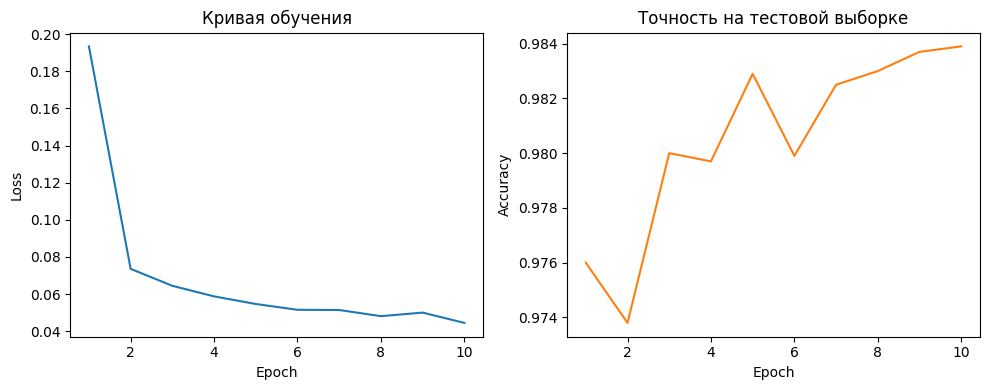

In [5]:
epochs = np.arange(1, EPOCH + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(epochs, loss_single_digit, color="tab:blue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Кривая обучения")
axes[1].plot(epochs, acc_single_digit, color="tab:orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Точность на тестовой выборке")
fig.tight_layout()
plt.show()

## Заводим вторую голвоу
Сделаем модель со второй головой, которая будет обучаться на датасете с одеждой

In [6]:
class OgreMagiCnn(nn.Module):
    def __init__(self, num_classes: int = 10) -> None:
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        feat_dim = 64 * 7 * 7
        self.head_digit = nn.Linear(feat_dim, num_classes)
        self.head_fashion = nn.Linear(feat_dim, num_classes)

    def forward(self, x: torch.Tensor, head: str = "digit") -> torch.Tensor:
        h = torch.flatten(self.body(x), start_dim=1)
        if head == "digit":
            return self.head_digit(h)
        if head == "fashion":
            return self.head_fashion(h)
        raise ValueError('head должен быть "digit" или "fashion"')

Сохраним состояние модели перед экспериментами

In [ ]:
model_digit_and_fashion = OgreMagiCnn().to(DEVICE)
model_digit_and_fashion.body.load_state_dict(model_single_digit.body.state_dict())
model_digit_and_fashion.head_digit.load_state_dict(model_single_digit.head_digit.state_dict())

os.makedirs(STATE_DIR, exist_ok=True)
torch.save(model_digit_and_fashion.state_dict(), STATE_PATH)

## эксперимент 1 - Обучаем вторую голову

In [8]:
for p in model_digit_and_fashion.body.parameters():
    p.requires_grad = False

optimizer_frozen_digit_and_fashion = optim.Adam(model_digit_and_fashion.head_fashion.parameters(), lr=LR)
loss_frozen_digit_and_fashion = []
acc_frozen_digit_and_fashion = []

for epoch in range(EPOCH):
    model_digit_and_fashion.train()
    running_loss = 0.0
    n_train = 0
    for xb, yb in tqdm(
        fashion_train_loader,
        desc=f"epoch {epoch + 1}/{EPOCH}",
        leave=False,
    ):
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer_frozen_digit_and_fashion.zero_grad(set_to_none=True)
        logits = model_digit_and_fashion(xb, head="fashion")
        loss_b = criterion_single_digit(logits, yb)
        loss_b.backward()
        optimizer_frozen_digit_and_fashion.step()
        running_loss += loss_b.item() * xb.size(0)
        n_train += xb.size(0)
    loss_frozen_digit_and_fashion.append(running_loss / n_train)

    model_digit_and_fashion.eval()
    correct = 0
    n_test = 0
    with torch.no_grad():
        for xb, yb in fashion_test_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            pred = model_digit_and_fashion(xb, head="fashion").argmax(dim=1)
            correct += (pred == yb).sum().item()
            n_test += yb.size(0)
    acc_frozen_digit_and_fashion.append(correct / n_test)
    print(
        f"epoch {epoch + 1}/{EPOCH}  "
        f"train_loss={loss_frozen_digit_and_fashion[-1]:.4f}  test_acc={acc_frozen_digit_and_fashion[-1]:.4f}"
    )

epoch 1/10  train_loss=0.5258  test_acc=0.8324


epoch 2/10  train_loss=0.4494  test_acc=0.8382


epoch 3/10  train_loss=0.4398  test_acc=0.8342


epoch 4/10  train_loss=0.4365  test_acc=0.8380


epoch 5/10  train_loss=0.4328  test_acc=0.8373


epoch 6/10  train_loss=0.4339  test_acc=0.8349


epoch 7/10  train_loss=0.4322  test_acc=0.8364


epoch 8/10  train_loss=0.4311  test_acc=0.8302


epoch 9/10  train_loss=0.4307  test_acc=0.8353


epoch 10/10  train_loss=0.4299  test_acc=0.8365


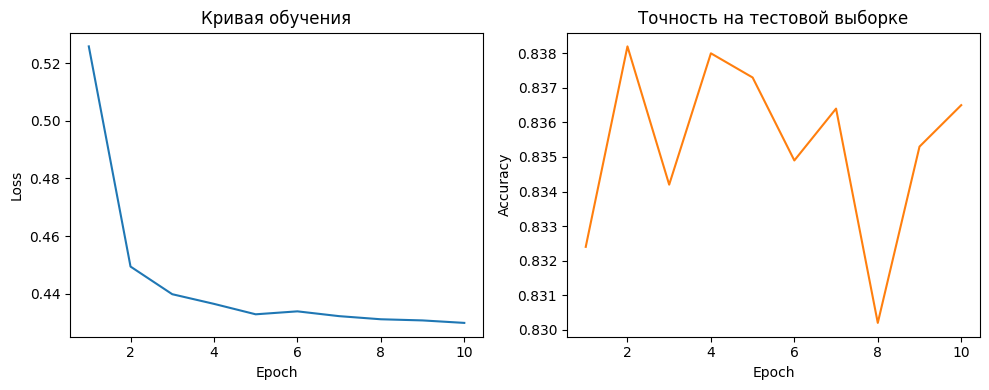

In [9]:
epochs = np.arange(1, EPOCH + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(epochs, loss_frozen_digit_and_fashion, color="tab:blue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Кривая обучения")
axes[1].plot(epochs, acc_frozen_digit_and_fashion, color="tab:orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Точность на тестовой выборке")
fig.tight_layout()
plt.show()

Размораживаем тело, и дообучаем всё вместе ещё 10 эпох

In [10]:
for p in model_digit_and_fashion.body.parameters():
    p.requires_grad = True

optimizer_finetune_digit_fashion = optim.Adam(
    list(model_digit_and_fashion.body.parameters())
    + list(model_digit_and_fashion.head_fashion.parameters()),
    lr=LR,
)

loss_finetuen_digit_fashion = []
acc_finetune_digit_fashion = []
loss_digit_head_finetune_digit_fashion = []
acc_digit_head_finetune_digit_fashion = []

for epoch in range(EPOCH):
    model_digit_and_fashion.train()
    running_loss = 0.0
    n_f = 0
    for xb, yb in tqdm(
        fashion_train_loader,
        desc=f"finetune {epoch + 1}/{EPOCH}",
        leave=False,
    ):
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer_finetune_digit_fashion.zero_grad(set_to_none=True)
        logits = model_digit_and_fashion(xb, head="fashion")
        loss_b = criterion_single_digit(logits, yb)
        loss_b.backward()
        optimizer_finetune_digit_fashion.step()
        running_loss += loss_b.item() * xb.size(0)
        n_f += xb.size(0)
    loss_finetuen_digit_fashion.append(running_loss / n_f)

    model_digit_and_fashion.eval()
    with torch.no_grad():
        correct_f = 0
        n_test_f = 0
        for xb, yb in fashion_test_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            pred = model_digit_and_fashion(xb, head="fashion").argmax(dim=1)
            correct_f += (pred == yb).sum().item()
            n_test_f += yb.size(0)
        acc_finetune_digit_fashion.append(correct_f / n_test_f)

        loss_m_sum = 0.0
        n_m = 0
        for xb, yb in mnist_train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits_m = model_digit_and_fashion(xb, head="digit")
            loss_m_sum += criterion_single_digit(logits_m, yb).item() * xb.size(0)
            n_m += xb.size(0)
        loss_digit_head_finetune_digit_fashion.append(loss_m_sum / n_m)

        correct_m = 0
        n_test_m = 0
        for xb, yb in mnist_test_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            pred = model_digit_and_fashion(xb, head="digit").argmax(dim=1)
            correct_m += (pred == yb).sum().item()
            n_test_m += yb.size(0)
        acc_digit_head_finetune_digit_fashion.append(correct_m / n_test_m)

    print(
        f"epoch {epoch + 1}/{EPOCH}  "
        f"f_loss={loss_finetuen_digit_fashion[-1]:.4f} f_acc={acc_finetune_digit_fashion[-1]:.4f}  "
        f"m_loss={loss_digit_head_finetune_digit_fashion[-1]:.4f} m_acc={acc_digit_head_finetune_digit_fashion[-1]:.4f}"
    )

epoch 1/10  f_loss=0.3840 f_acc=0.8662  m_loss=0.0632 m_acc=0.9753


epoch 2/10  f_loss=0.3328 f_acc=0.8677  m_loss=0.1145 m_acc=0.9613


epoch 3/10  f_loss=0.3090 f_acc=0.8806  m_loss=0.1042 m_acc=0.9666


epoch 4/10  f_loss=0.2928 f_acc=0.8814  m_loss=0.1452 m_acc=0.9538


epoch 5/10  f_loss=0.2844 f_acc=0.8851  m_loss=0.1602 m_acc=0.9492


epoch 6/10  f_loss=0.2795 f_acc=0.8843  m_loss=0.1996 m_acc=0.9385


epoch 7/10  f_loss=0.2668 f_acc=0.8900  m_loss=0.1547 m_acc=0.9519


epoch 8/10  f_loss=0.2703 f_acc=0.8908  m_loss=0.1873 m_acc=0.9430


epoch 9/10  f_loss=0.2645 f_acc=0.8758  m_loss=0.2541 m_acc=0.9234


epoch 10/10  f_loss=0.2637 f_acc=0.8948  m_loss=0.2194 m_acc=0.9322


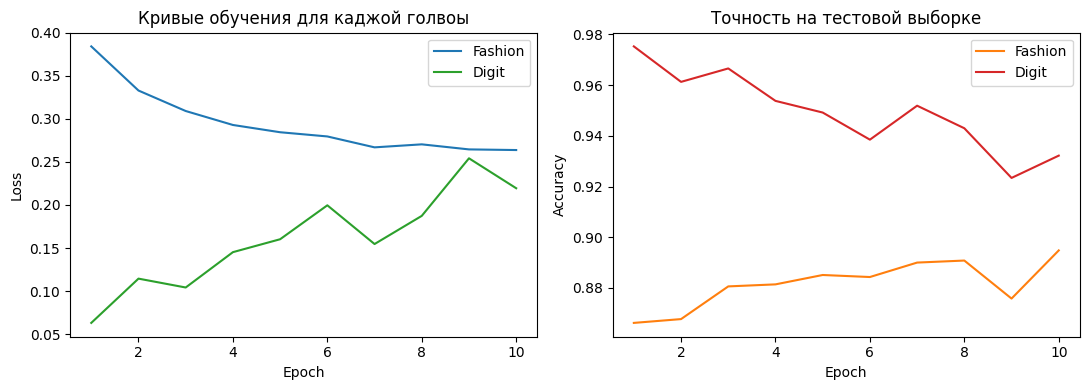

In [11]:
epochs = np.arange(1, EPOCH + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(
    epochs, loss_finetuen_digit_fashion, color="tab:blue", label="Fashion"
)
axes[0].plot(
    epochs,
    loss_digit_head_finetune_digit_fashion,
    color="tab:green",
    label="Digit",
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Кривые обучения для каджой голвоы")
axes[0].legend()
axes[1].plot(
    epochs, acc_finetune_digit_fashion, color="tab:orange", label="Fashion"
)
axes[1].plot(epochs, acc_digit_head_finetune_digit_fashion, color="tab:red", label="Digit")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Точность на тестовой выборке")
axes[1].legend()
fig.tight_layout()
plt.show()

# Эксперимент 2 - обучение второй головы сразу с размороженными весами
Загружаем сохраненное состояние и файнтюним со всеми размороженными слоями

In [ ]:
model_unfrozen_finetune_digit_fashion = OgreMagiCnn().to(DEVICE)
model_unfrozen_finetune_digit_fashion.load_state_dict(torch.load(STATE_PATH, map_location=DEVICE))

optimizer_unfrozen_finetune_digit_fashion = optim.Adam(
    list(model_unfrozen_finetune_digit_fashion.body.parameters()) + list(model_unfrozen_finetune_digit_fashion.head_fashion.parameters()),
    lr=LR,
)

loss_unforzen_fashion_head = []
acc_unfrozen_fashion_head = []
loss_unfrozen_digit_head = []
acc_unfrozen_digit_head = []

for epoch in range(EPOCH):
    model_unfrozen_finetune_digit_fashion.train()
    running_loss = 0.0
    n_f = 0
    for xb, yb in tqdm(
        fashion_train_loader,
        desc=f"p8 {epoch + 1}/{EPOCH}",
        leave=False,
    ):
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer_unfrozen_finetune_digit_fashion.zero_grad(set_to_none=True)
        logits = model_unfrozen_finetune_digit_fashion(xb, head="fashion")
        loss_b = criterion_single_digit(logits, yb)
        loss_b.backward()
        optimizer_unfrozen_finetune_digit_fashion.step()
        running_loss += loss_b.item() * xb.size(0)
        n_f += xb.size(0)
    loss_unforzen_fashion_head.append(running_loss / n_f)

    model_unfrozen_finetune_digit_fashion.eval()
    with torch.no_grad():
        correct_f = 0
        n_test_f = 0
        for xb, yb in fashion_test_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            pred = model_unfrozen_finetune_digit_fashion(xb, head="fashion").argmax(dim=1)
            correct_f += (pred == yb).sum().item()
            n_test_f += yb.size(0)
        acc_unfrozen_fashion_head.append(correct_f / n_test_f)

        loss_m_sum = 0.0
        n_m = 0
        for xb, yb in mnist_train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits_m = model_unfrozen_finetune_digit_fashion(xb, head="digit")
            loss_m_sum += criterion_single_digit(logits_m, yb).item() * xb.size(0)
            n_m += xb.size(0)
        loss_unfrozen_digit_head.append(loss_m_sum / n_m)

        correct_m = 0
        n_test_m = 0
        for xb, yb in mnist_test_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            pred = model_unfrozen_finetune_digit_fashion(xb, head="digit").argmax(dim=1)
            correct_m += (pred == yb).sum().item()
            n_test_m += yb.size(0)
        acc_unfrozen_digit_head.append(correct_m / n_test_m)

    print(
        f"epoch {epoch + 1}/{EPOCH}  "
        f"f_loss={loss_unforzen_fashion_head[-1]:.4f} f_acc={acc_unfrozen_fashion_head[-1]:.4f}  "
        f"m_loss={loss_unfrozen_digit_head[-1]:.4f} m_acc={acc_unfrozen_digit_head[-1]:.4f}"
    )

epoch 1/10  f_loss=0.4095 f_acc=0.8627  m_loss=0.2354 m_acc=0.9463


epoch 2/10  f_loss=0.3150 f_acc=0.8585  m_loss=0.2230 m_acc=0.9456


epoch 3/10  f_loss=0.2919 f_acc=0.8825  m_loss=0.3120 m_acc=0.9207


epoch 4/10  f_loss=0.2823 f_acc=0.8832  m_loss=0.3376 m_acc=0.9146


epoch 5/10  f_loss=0.2753 f_acc=0.8875  m_loss=0.3413 m_acc=0.9168


epoch 6/10  f_loss=0.2670 f_acc=0.8865  m_loss=0.3208 m_acc=0.9120


epoch 7/10  f_loss=0.2641 f_acc=0.8864  m_loss=0.3388 m_acc=0.9134


epoch 8/10  f_loss=0.2613 f_acc=0.8892  m_loss=0.3732 m_acc=0.8960


epoch 9/10  f_loss=0.2543 f_acc=0.8925  m_loss=0.3100 m_acc=0.9189


epoch 10/10  f_loss=0.2524 f_acc=0.8899  m_loss=0.8206 m_acc=0.7960


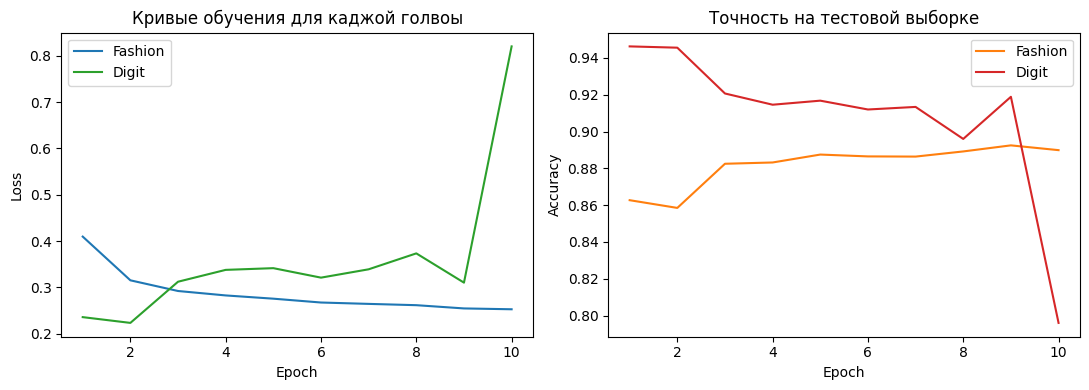

In [13]:
epochs = np.arange(1, EPOCH + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(
    epochs, loss_unforzen_fashion_head, color="tab:blue", label="Fashion"
)
axes[0].plot(
    epochs,
    loss_unfrozen_digit_head,
    color="tab:green",
    label="Digit",
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Кривые обучения для каджой голвоы")
axes[0].legend()
axes[1].plot(
    epochs, acc_unfrozen_fashion_head, color="tab:orange", label="Fashion"
)
axes[1].plot(epochs, acc_unfrozen_digit_head, color="tab:red", label="Digit")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Точность на тестовой выборке")
axes[1].legend()
fig.tight_layout()
plt.show()

## Эксперимент 3 - обучение со случайными весами

In [14]:
FROZEN_BODY_PARTS = 1

model_random = OgreMagiCnn().to(DEVICE)

for p in model_random.head_digit.parameters():
    p.requires_grad = False

conv_seen = 0
for layer in model_random.body.children():
    if isinstance(layer, nn.Conv2d):
        freeze = conv_seen < FROZEN_BODY_PARTS
        for p in layer.parameters():
            p.requires_grad = not freeze
        conv_seen += 1

trainable_random = [p for p in model_random.parameters() if p.requires_grad]
optimizer_random = optim.Adam(trainable_random, lr=LR)

loss_random = []
acc_random = []

for epoch in range(EPOCH):
    model_random.train()
    running_loss = 0.0
    n_f = 0
    for xb, yb in tqdm(
        fashion_train_loader,
        desc=f"p9 {epoch + 1}/{EPOCH}",
        leave=False,
    ):
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer_random.zero_grad(set_to_none=True)
        logits = model_random(xb, head="fashion")
        loss_b = criterion_single_digit(logits, yb)
        loss_b.backward()
        optimizer_random.step()
        running_loss += loss_b.item() * xb.size(0)
        n_f += xb.size(0)
    loss_random.append(running_loss / n_f)

    model_random.eval()
    correct = 0
    n_test = 0
    with torch.no_grad():
        for xb, yb in fashion_test_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            pred = model_random(xb, head="fashion").argmax(dim=1)
            correct += (pred == yb).sum().item()
            n_test += yb.size(0)
    acc_random.append(correct / n_test)
    print(
        f"epoch {epoch + 1}/{EPOCH}  "
        f"train_loss={loss_random[-1]:.4f}  test_acc={acc_random[-1]:.4f}"
    )

epoch 1/10  train_loss=0.4921  test_acc=0.8613


epoch 2/10  train_loss=0.3547  test_acc=0.8574


epoch 3/10  train_loss=0.3331  test_acc=0.8743


epoch 4/10  train_loss=0.3189  test_acc=0.8798


epoch 5/10  train_loss=0.3143  test_acc=0.8833


epoch 6/10  train_loss=0.3068  test_acc=0.8786


epoch 7/10  train_loss=0.3079  test_acc=0.8811


epoch 8/10  train_loss=0.2997  test_acc=0.8759


epoch 9/10  train_loss=0.2932  test_acc=0.8844


epoch 10/10  train_loss=0.2969  test_acc=0.8839


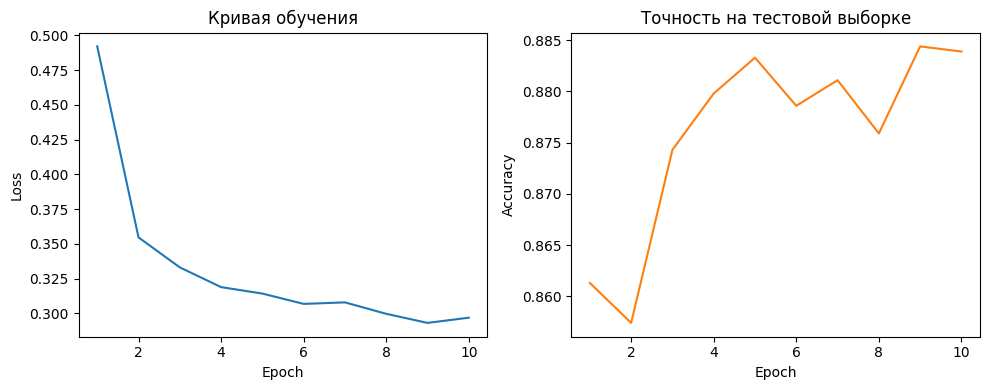

In [15]:
epochs = np.arange(1, EPOCH + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(epochs, loss_random, color="tab:blue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Кривая обучения")
axes[1].plot(epochs, acc_random, color="tab:orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Точность на тестовой выборке")
fig.tight_layout()
plt.show()

## Итоги, лучшая модель

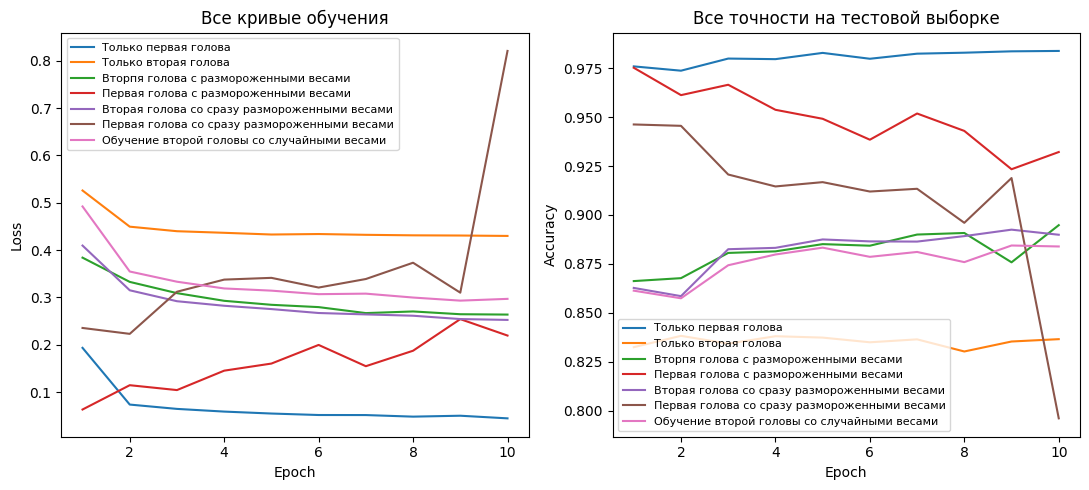

In [19]:
epochs = np.arange(1, EPOCH + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
loss_runs = [
    (loss_single_digit, "Только первая голова"),
    (loss_frozen_digit_and_fashion, "Только вторая голова"),
    (loss_finetuen_digit_fashion, "Вторпя голова с размороженными весами"),
    (loss_digit_head_finetune_digit_fashion, "Первая голова с размороженными весами"),
    (loss_unforzen_fashion_head, "Вторая голова со сразу размороженными весами"),
    (loss_unfrozen_digit_head, "Первая голова со сразу размороженными весами"),
    (loss_random, "Обучение второй головы со случайными весами"),
]
for data, lab in loss_runs:
    y = np.asarray(data[:EPOCH])
    axes[0].plot(epochs[: len(y)], y, label=lab)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Все кривые обучения")
axes[0].legend(fontsize=8, loc="best")
acc_runs = [
    (acc_single_digit, "Только первая голова"),
    (acc_frozen_digit_and_fashion, "Только вторая голова"),
    (acc_finetune_digit_fashion, "Вторпя голова с размороженными весами"),
    (acc_digit_head_finetune_digit_fashion, "Первая голова с размороженными весами"),
    (acc_unfrozen_fashion_head, "Вторая голова со сразу размороженными весами"),
    (acc_unfrozen_digit_head, "Первая голова со сразу размороженными весами"),
    (acc_random, "Обучение второй головы со случайными весами"),
]
for data, lab in acc_runs:
    y = np.asarray(data[:EPOCH])
    axes[1].plot(epochs[: len(y)], y, label=lab)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Все точности на тестовой выборке")
axes[1].legend(fontsize=8, loc="best")
fig.tight_layout()
plt.show()

## Пункт 11. Лучшая модель для Fashion-MNIST и пары классов (c, t)

**Лучшая модель** — среди вариантов после **п.7** (`model_dual`), **п.8** (`model_p8`) и **п.9** (`model_p9`) по **финальной test accuracy** на Fashion.

Для каждой пары **(c, t)** на **тестовой** выборке смотрим только примеры с **истинным классом c**. Среди них выбираем изображение с **наибольшим логитом** (скором) для класса **t** — у модели это образец класса **c**, который она «больше всего относит» к **t**. Для **softmax**-вероятностей индекс максимума по тем же объектам совпал бы с тем же выбором.

Сетка **10×10**: строка **c**, столбец **t**. Ячейки **c = t** на рисунке **пустые**: для такой пары критерий вырождается в «самый уверенный пример своего класса», а не в сходство с **другим** классом **t**.

Лучшая модель: Дообучение с замороженными весами
Итоговая точность = 0.8948


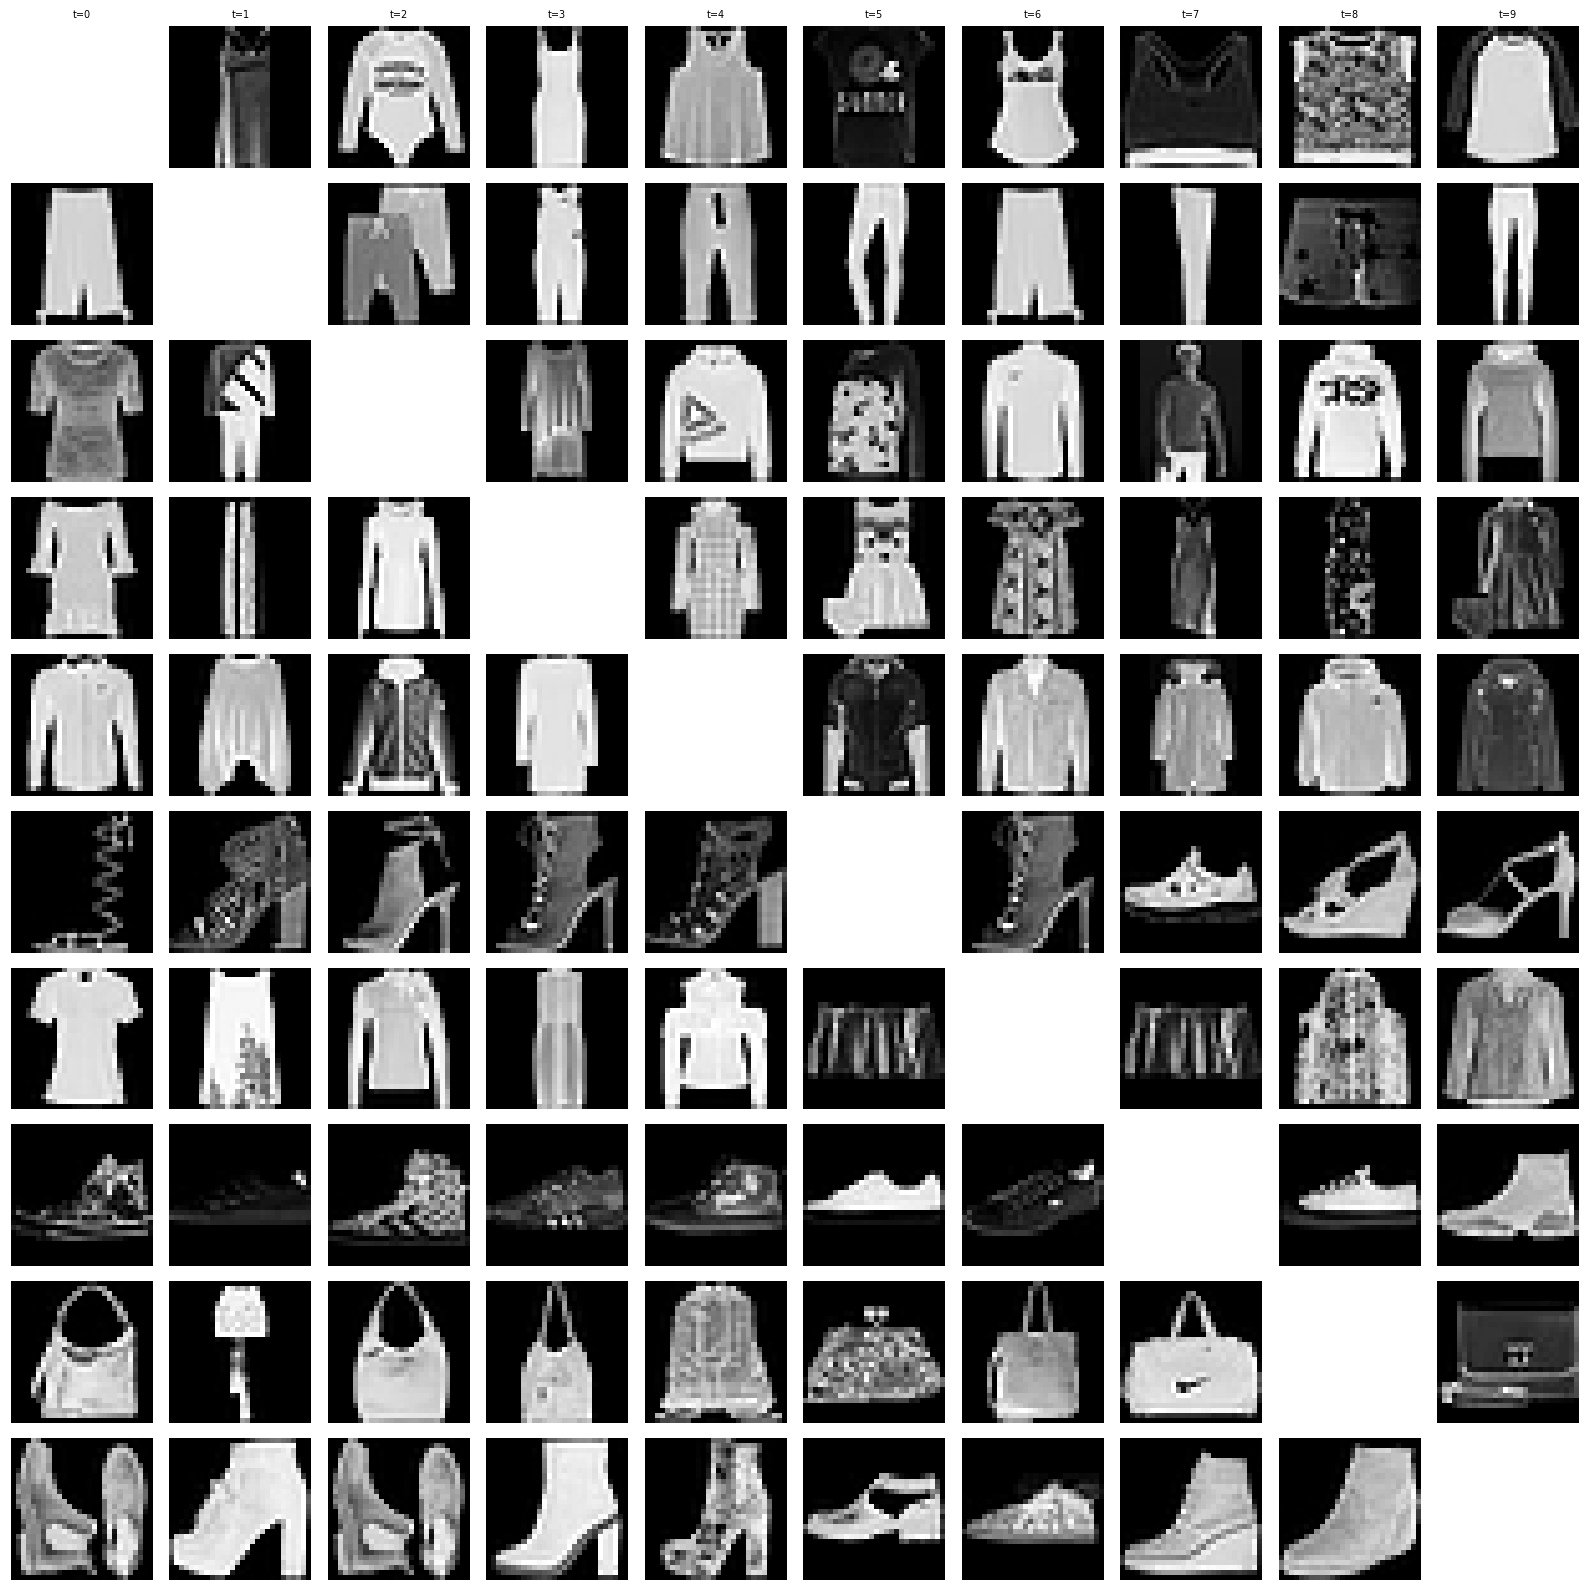

In [17]:
acc_candidates = [
    (acc_finetune_digit_fashion[-1], "Дообучение с замороженными весами", model_digit_and_fashion),
    (acc_unfrozen_fashion_head[-1], "Дообучение с размороженными весами", model_unfrozen_finetune_digit_fashion),
    (acc_random[-1], "Дообучение с рандомынми весами", model_random),
]
print("Лучшая модель:", max(acc_candidates, key=lambda x: x[0])[1])
best_acc, best_label, best_fashion_model = max(acc_candidates, key=lambda x: x[0])
print(f"Итоговая точность = {best_acc:.4f}")

best_fashion_model.eval()
all_x, all_y, all_logits = [], [], []
with torch.no_grad():
    for xb, yb in fashion_test_loader:
        xb = xb.to(DEVICE)
        logits = best_fashion_model(xb, head="fashion")
        all_x.append(xb.cpu())
        all_y.append(yb.clone())
        all_logits.append(logits.cpu())
all_x = torch.cat(all_x, dim=0)
all_y = torch.cat(all_y, dim=0)
all_logits = torch.cat(all_logits, dim=0)

fig, axes = plt.subplots(10, 10, figsize=(16, 16))
for c in range(10):
    for t in range(10):
        ax = axes[c, t]
        if c == t:
            if c == 0:
                ax.set_title(f"t={t}", fontsize=7)
            if t == 0:
                ax.set_ylabel(f"c={c}", fontsize=7, rotation=90, labelpad=4)
            ax.set_facecolor("0.92")
            ax.axis("off")
            continue
        mask = all_y == c
        logits_c = all_logits[mask]
        imgs_c = all_x[mask]
        j = int(logits_c[:, t].argmax())
        ax.imshow(imgs_c[j].squeeze().numpy(), cmap="gray")
        ax.axis("off")
        if c == 0:
            ax.set_title(f"t={t}", fontsize=7)
        if t == 0:
            ax.set_ylabel(f"c={c}", fontsize=7, rotation=90, labelpad=4)
plt.tight_layout()
plt.show()